In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Geometry Intuition

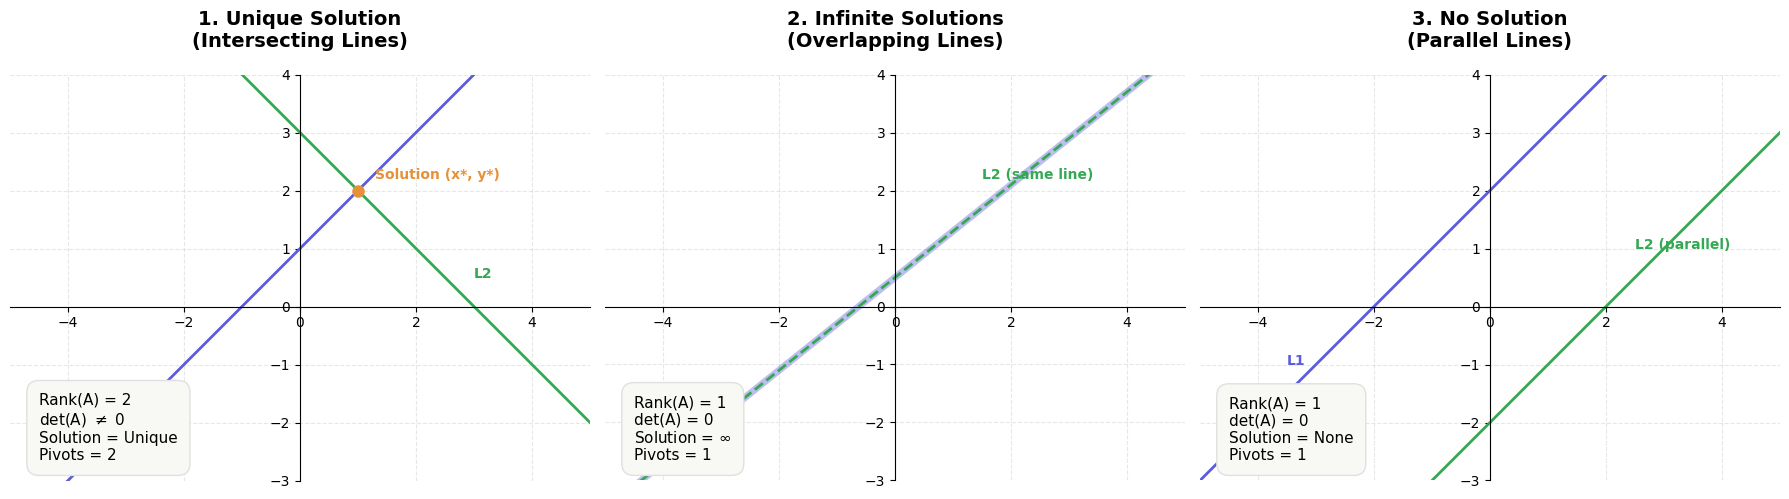

In [2]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

def style_ax(ax, title):
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-3, 4)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_title(title, fontweight='bold', fontsize=14, pad=20)

x = np.linspace(-6, 6, 100)

style_ax(axs[0], "1. Unique Solution\n(Intersecting Lines)")
y1_a = x + 1
y2_a = -x + 3
axs[0].plot(x, y1_a, color='#5C5CDB', lw=2)
axs[0].plot(x, y2_a, color='#34A853', lw=2)
axs[0].plot(1, 2, marker='o', color='#E69138', markersize=8, zorder=5)
axs[0].text(-3, -1.5, "L1", color='#5C5CDB', fontweight='bold')
axs[0].text(3, 0.5, "L2", color='#34A853', fontweight='bold')
axs[0].text(1.3, 2.2, "Solution (x*, y*)", color='#E69138', fontweight='bold')

info_1 = "Rank(A) = 2\ndet(A) $\\neq$ 0\nSolution = Unique\nPivots = 2"
axs[0].text(0.05, 0.05, info_1, transform=axs[0].transAxes, fontsize=11,
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F8F8F5', edgecolor='#E0E0E0'))


style_ax(axs[1], "2. Infinite Solutions\n(Overlapping Lines)")
y1_b = 0.8 * x + 0.5
axs[1].plot(x, y1_b, color='#5C5CDB', lw=5, alpha=0.4)
axs[1].plot(x, y1_b, color='#34A853', lw=2, linestyle='--')
axs[1].text(-3, -1.5, "L1", color='#5C5CDB', fontweight='bold')
axs[1].text(1.5, 2.2, "L2 (same line)", color='#34A853', fontweight='bold')

info_2 = "Rank(A) = 1\ndet(A) = 0\nSolution = $\\infty$\nPivots = 1"
axs[1].text(0.05, 0.05, info_2, transform=axs[1].transAxes, fontsize=11,
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F8F8F5', edgecolor='#E0E0E0'))


style_ax(axs[2], "3. No Solution\n(Parallel Lines)")
y1_c = x + 2
y2_c = x - 2
axs[2].plot(x, y1_c, color='#5C5CDB', lw=2)
axs[2].plot(x, y2_c, color='#34A853', lw=2)
axs[2].text(-3.5, -1, "L1", color='#5C5CDB', fontweight='bold')
axs[2].text(2.5, 1, "L2 (parallel)", color='#34A853', fontweight='bold')

info_3 = "Rank(A) = 1\ndet(A) = 0\nSolution = None\nPivots = 1"
axs[2].text(0.05, 0.05, info_3, transform=axs[2].transAxes, fontsize=11,
            bbox=dict(boxstyle='round,pad=0.8', facecolor='#F8F8F5', edgecolor='#E0E0E0'))

plt.tight_layout()
plt.show()

> System of Linear Equation 
 Ax=b is simple means of "is there a vector x such that when transformed by A, it yields b?" Geometrically, each equation represents a hyperplane in n-dimensional space. The solution is the intersection of all those hyperplanes.
- 1 unique solution appears when 2 line intersect exactly at one single point. Matrix A invertible (det ≠ 0). Its ideal case when always one definite answer
- infinite solution appears when 2 line identically (overlap). Matrix A rank-deficient doesnt have enough constraints to pin down 1 solution 
- No solution means 2 paralel line (unintersect), there is no point satisfies both conditions 

# Gaussian Elimination

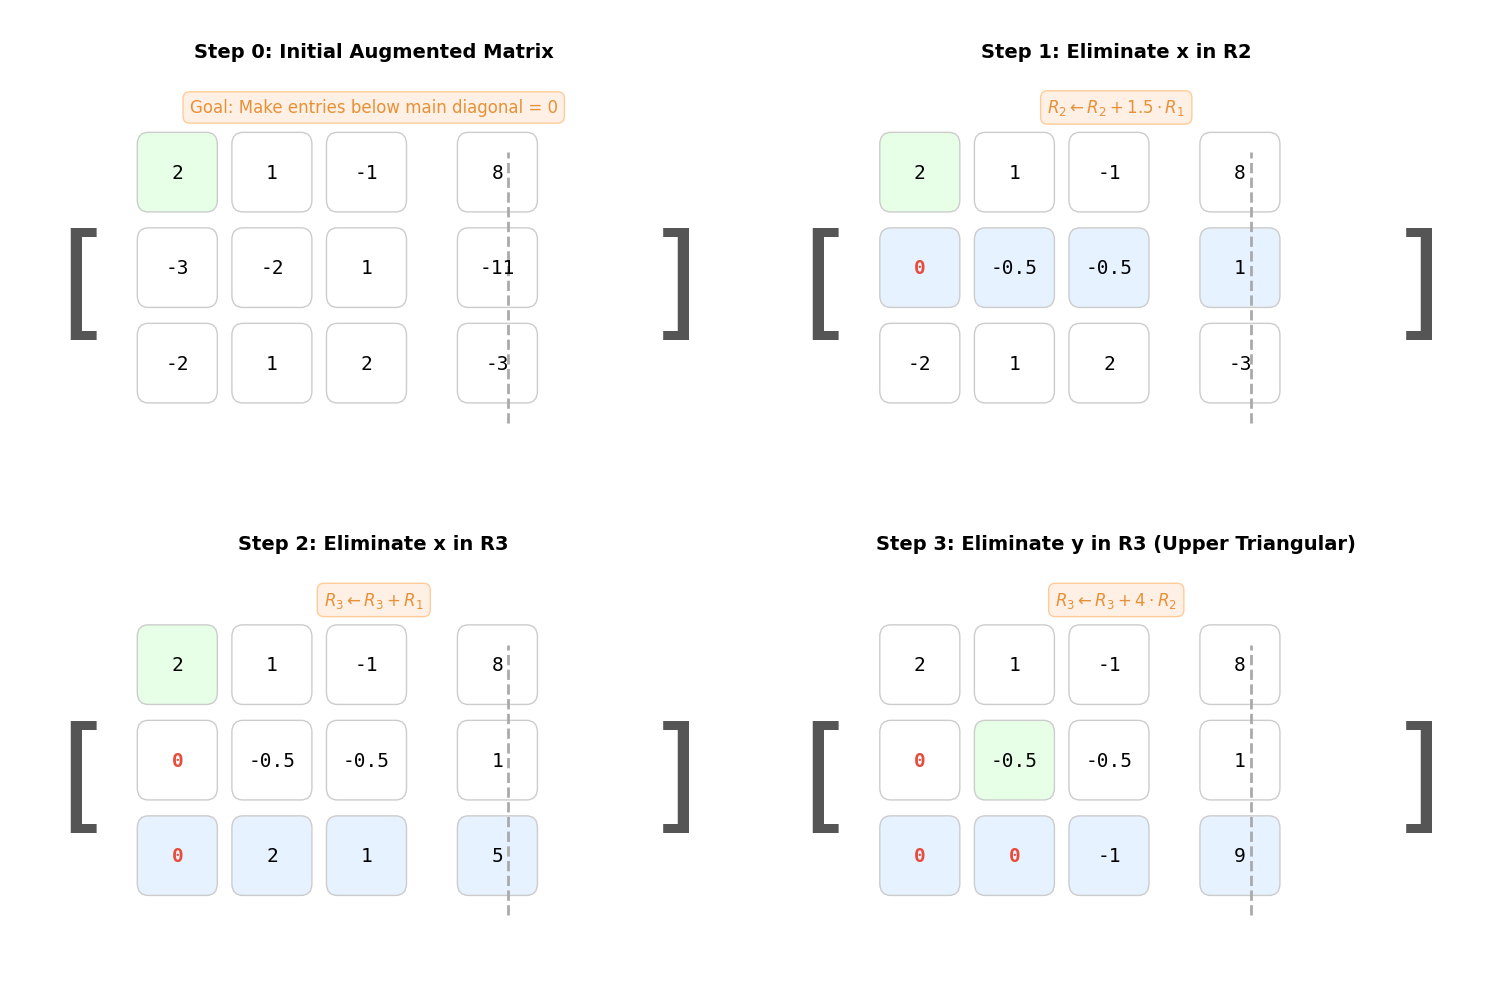

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

matrices = [
    [[2, 1, -1, 8], [-3, -2, 1, -11], [-2, 1, 2, -3]],
    [[2, 1, -1, 8], [0, -0.5, -0.5, 1], [-2, 1, 2, -3]],
    [[2, 1, -1, 8], [0, -0.5, -0.5, 1], [0, 2, 1, 5]],
    [[2, 1, -1, 8], [0, -0.5, -0.5, 1], [0, 0, -1, 9]]
]

titles = [
    "Step 0: Initial Augmented Matrix",
    "Step 1: Eliminate x in R2",
    "Step 2: Eliminate x in R3",
    "Step 3: Eliminate y in R3 (Upper Triangular)"
]

operations = [
    "Goal: Make entries below main diagonal = 0",
    r"$R_2 \leftarrow R_2 + 1.5 \cdot R_1$",
    r"$R_3 \leftarrow R_3 + R_1$",
    r"$R_3 \leftarrow R_3 + 4 \cdot R_2$"
]

highlights = [
    {'pivot': (0,0), 'target': None},
    {'pivot': (0,0), 'target': 1},
    {'pivot': (0,0), 'target': 2},
    {'pivot': (1,1), 'target': 2}
]

def draw_matrix(ax, mat, title, op, hl):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis('off')
    
    ax.text(5, 5.4, title, fontsize=14, fontweight='bold', ha='center')
    ax.text(5, 4.7, op, fontsize=12, color='#E69138', ha='center',
            bbox=dict(facecolor='#fff0e6', edgecolor='#ffcc99', boxstyle='round,pad=0.4'))
    
    ax.text(1.2, 2.5, r"$[$", fontsize=90, ha='right', va='center', color='#555555')
    ax.text(8.8, 2.5, r"$]$", fontsize=90, ha='left', va='center', color='#555555')
    
    ax.plot([6.85, 6.85], [0.8, 4.2], color='#aaaaaa', lw=2, linestyle='--')
    
    for i in range(3):
        for j in range(4):
            val = mat[i][j]
            x = 1.8 + j * 1.3
            if j == 3: x += 0.5 
            y = 3.5 - i * 1.2
            
            fc = 'white'
            if hl['pivot'] == (i, j):
                fc = '#e6ffe6'
            elif hl['target'] == i:
                fc = '#e6f2ff'
            
            rect = patches.FancyBboxPatch(
                (x, y), 1.0, 0.9,
                boxstyle="round,pad=0.05,rounding_size=0.15",
                linewidth=1, edgecolor='#cccccc', facecolor=fc
            )
            ax.add_patch(rect)
            
            val_str = f"{val:g}"
            if val == 0 and i > 0 and j < i:
                color = '#E74C3C'
                fw = 'bold'
            else:
                color = 'black'
                fw = 'normal'
                
            ax.text(x + 0.5, y + 0.45, val_str, ha='center', va='center', 
                    fontsize=14, fontfamily='monospace', color=color, fontweight=fw)

for i in range(4):
    draw_matrix(axs[i], matrices[i], titles[i], operations[i], highlights[i])

plt.tight_layout()
plt.show()

> Gaussian elimination, the idea is so simple utilize just three operation that not change the result(switch rows, calculated with scalar, linear combination with other rows) for change A become upper triangular. After that solve from down to up (back subtitution) easy due to each row just have 1 unknown unsolved. Idea:
- the goals is easy that is making left side like..
    - $\begin{bmatrix}* & * & * \\0 & * & * \\0 & 0 & *\end{bmatrix}$ <- Row Echelon Form

# LU Decomposition

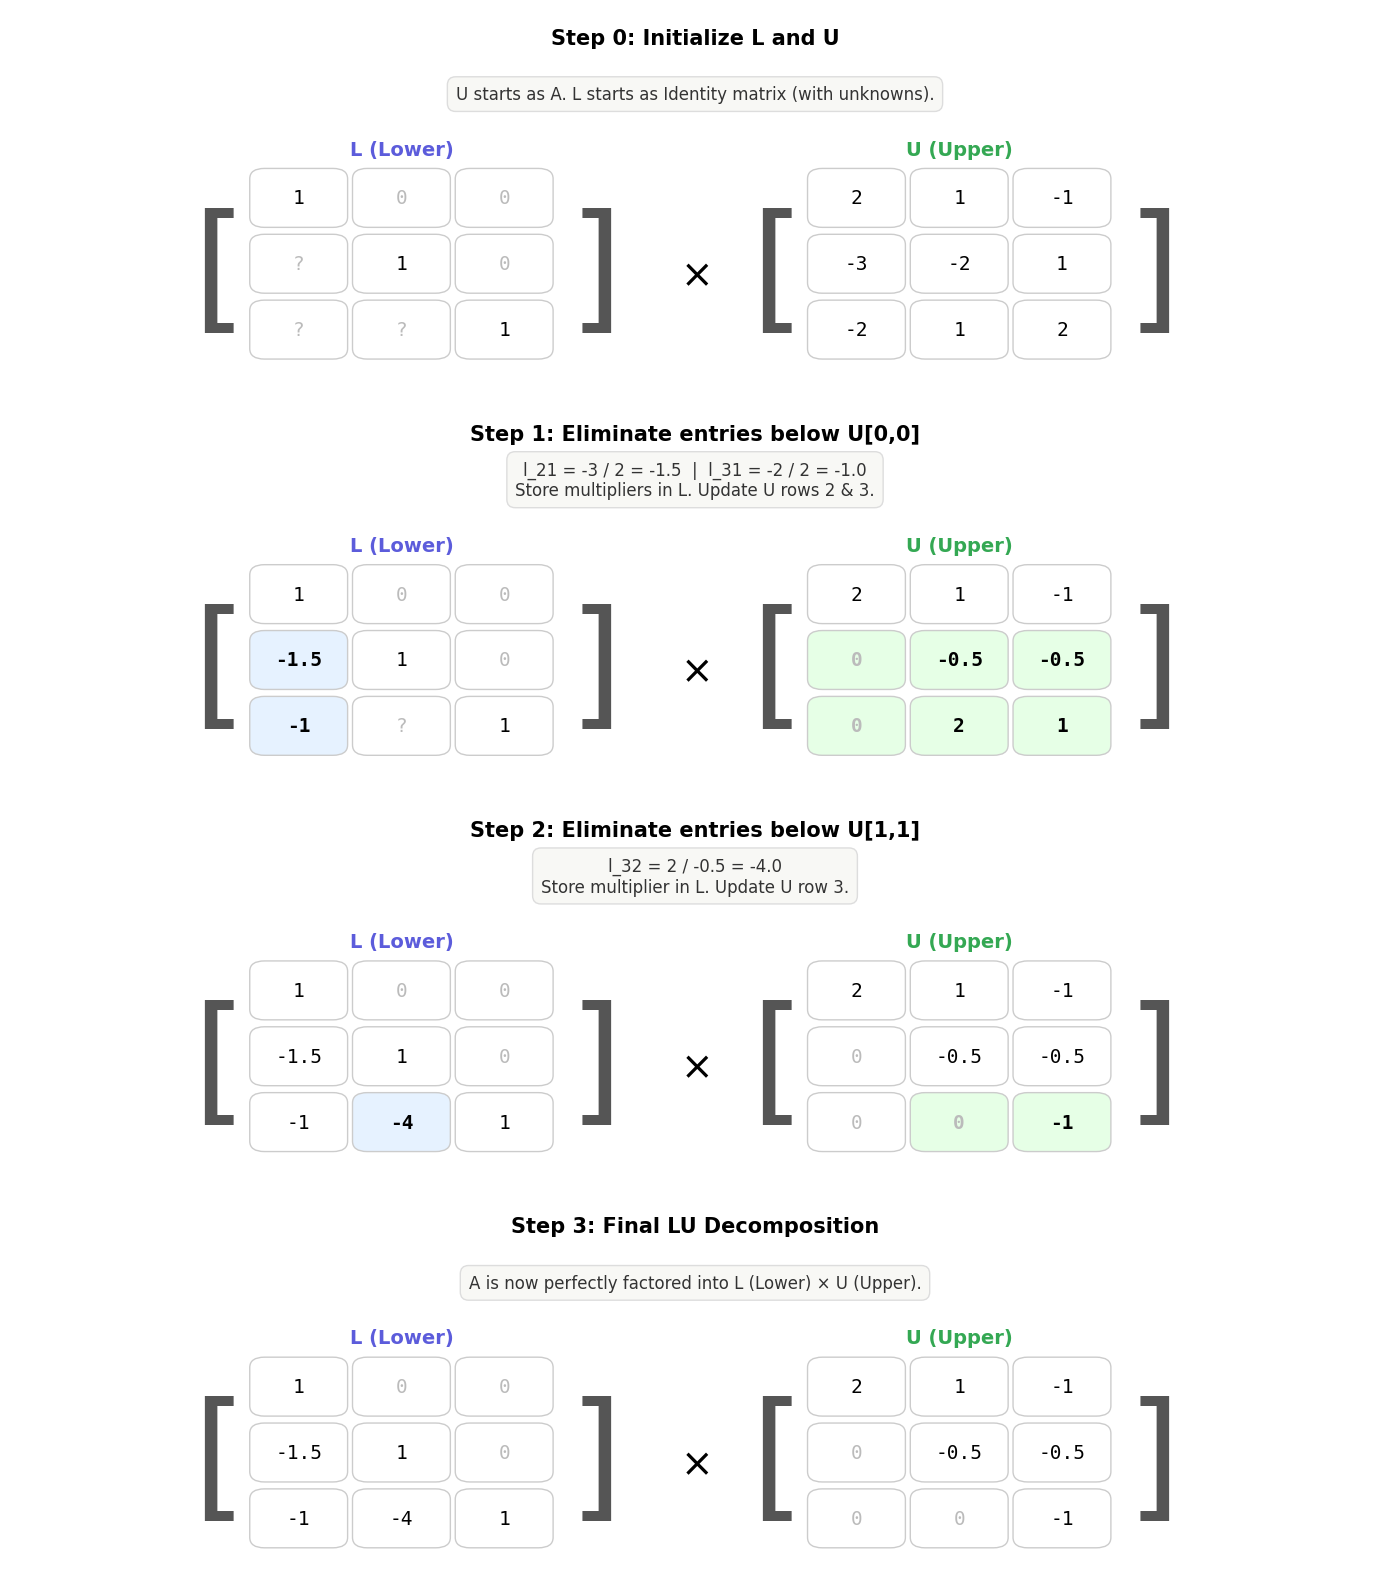

In [6]:
fig, axs = plt.subplots(4, 1, figsize=(14, 16))

steps = [
    {
        "title": "Step 0: Initialize L and U",
        "op": "U starts as A. L starts as Identity matrix (with unknowns).",
        "L": [[1, 0, 0], ["?", 1, 0], ["?", "?", 1]],
        "U": [[2, 1, -1], [-3, -2, 1], [-2, 1, 2]],
        "hl_L": [],
        "hl_U": []
    },
    {
        "title": "Step 1: Eliminate entries below U[0,0]",
        "op": "l_21 = -3 / 2 = -1.5  |  l_31 = -2 / 2 = -1.0\nStore multipliers in L. Update U rows 2 & 3.",
        "L": [[1, 0, 0], [-1.5, 1, 0], [-1.0, "?", 1]],
        "U": [[2, 1, -1], [0, -0.5, -0.5], [0, 2, 1]],
        "hl_L": [(1,0), (2,0)],
        "hl_U": [(1,0), (2,0), (1,1), (1,2), (2,1), (2,2)]
    },
    {
        "title": "Step 2: Eliminate entries below U[1,1]",
        "op": "l_32 = 2 / -0.5 = -4.0\nStore multiplier in L. Update U row 3.",
        "L": [[1, 0, 0], [-1.5, 1, 0], [-1.0, -4.0, 1]],
        "U": [[2, 1, -1], [0, -0.5, -0.5], [0, 0, -1]],
        "hl_L": [(2,1)],
        "hl_U": [(2,1), (2,2)]
    },
    {
        "title": "Step 3: Final LU Decomposition",
        "op": "A is now perfectly factored into L (Lower) × U (Upper).",
        "L": [[1, 0, 0], [-1.5, 1, 0], [-1.0, -4.0, 1]],
        "U": [[2, 1, -1], [0, -0.5, -0.5], [0, 0, -1]],
        "hl_L": [],
        "hl_U": []
    }
]

def draw_lu_step(ax, data):
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 5.5)
    ax.axis('off')

    ax.text(7, 5.0, data["title"], fontsize=15, fontweight='bold', ha='center')
    ax.text(7, 4.2, data["op"], fontsize=12, color='#333333', ha='center',
            bbox=dict(facecolor='#F8F8F5', edgecolor='#dddddd', boxstyle='round,pad=0.5'))

    def draw_matrix(x_offset, mat, name, hl_cells, is_L=False):
        ax.text(x_offset + 1.5, 3.4, name, fontsize=14, fontweight='bold', color='#5C5CDB' if is_L else '#34A853', ha='center')
        ax.text(x_offset - 0.2, 1.675, r"$[$", fontsize=100, ha='right', va='center', color='#555555')
        ax.text(x_offset + 3.2, 1.675, r"$]$", fontsize=100, ha='left', va='center', color='#555555')

        for i in range(3):
            for j in range(3):
                val = mat[i][j]
                x = x_offset + j * 1.05
                y = 2.4 - i * 0.95

                fc = 'white'
                if (i, j) in hl_cells:
                    fc = '#e6f2ff' if is_L else '#e6ffe6'
                
                is_structural_zero = (is_L and i < j) or (not is_L and i > j)
                
                if is_structural_zero and val == 0:
                    text_c = '#bbbbbb'
                elif val == "?":
                    text_c = '#bbbbbb'
                else:
                    text_c = 'black'

                rect = patches.FancyBboxPatch(
                    (x, y), 0.9, 0.75,
                    boxstyle="round,pad=0.05,rounding_size=0.15",
                    linewidth=1, edgecolor='#cccccc', facecolor=fc
                )
                ax.add_patch(rect)

                val_str = str(val) if isinstance(val, str) else f"{val:g}"
                fw = 'bold' if (i, j) in hl_cells else 'normal'
                ax.text(x + 0.45, y + 0.375, val_str, ha='center', va='center',
                        fontsize=14, fontfamily='monospace', color=text_c, fontweight=fw)

    draw_matrix(2.5, data["L"], "L (Lower)", data["hl_L"], is_L=True)
    ax.text(7, 1.675, r"$\times$", fontsize=28, fontweight='bold', ha='center', va='center')
    draw_matrix(8.2, data["U"], "U (Upper)", data["hl_U"], is_L=False)

for i in range(4):
    draw_lu_step(axs[i], steps[i])

plt.tight_layout()
plt.show()

> LU Decomposition, it save all gaussian elim step in form of 2 matrix: L(lower triangular contains multipliers) and U(upper triangular the result of elimination)
- A = LU
- If u need to solve Ax=b for some different b value but A still remain(let say u trained neur nets with different batch). LU become more efficient factor A, factorize A once in O(n³), and then for each b, it only takes O(n²).

# Some Exercise

### 💡 Eliminasi Gauss

To solve the sys linear equation:
$$
\begin{cases} 
x + y + z = 6 \\
2x - y + z = 3 \\
-x + 2y - z = 3 
\end{cases}
$$

Extended matrix representation:
$$
\left[
\begin{array}{ccc|c}
1 & 1 & 1 & 6 \\
2 & -1 & 1 & 3 \\
-1 & 2 & -1 & 3
\end{array}
\right]
$$

**Step by step elimination:**

1. Operation $R_3 + R_1 \rightarrow R_3$:
$$
\left[
\begin{array}{ccc|c}
1 & 1 & 1 & 6 \\
2 & -1 & 1 & 3 \\
0 & 3 & 0 & 9
\end{array}
\right]
$$

2. Operation $R_2 - 2R_1 \rightarrow R_2$:
$$
\left[
\begin{array}{ccc|c}
1 & 1 & 1 & 6 \\
0 & -3 & -1 & -9 \\
0 & 3 & 0 & 9
\end{array}
\right]
$$

3. Operation $R_3 + R_2 \rightarrow R_3$:
$$
\left[
\begin{array}{ccc|c}
1 & 1 & 1 & 6 \\
0 & -3 & -1 & -9 \\
0 & 0 & -1 & 0
\end{array}
\right]
$$

**Final Result:**
Dari baris ke-3, didapat $-z = 0 \rightarrow \mathbf{z = 0}$.
Substitusi ke baris ke-2: $-3y - 0 = -9 \rightarrow \mathbf{y = 3}$.
Substitusi ke baris ke-1: $x + 3 + 0 = 6 \rightarrow \mathbf{x = 3}$.

So, the solution is **(3, 3, 0)**.

### 💡 LU Decomposition

Given matrix $A$:
$$
A = \begin{bmatrix} 
1 & 1 & 1 \\ 
2 & -1 & 1 \\ 
-1 & 2 & -1 
\end{bmatrix}
$$

Our goals is decompose matrix $A$ become $A = LU$.

1\. Determine Matrix U (Upper Triangular)
Matrix $U$ obtained from final result of gauss elim
$$
U = \begin{bmatrix} 
1 & 1 & 1 \\ 
0 & -3 & -1 \\ 
0 & 0 & -1 
\end{bmatrix}
$$

2\. Determine Matrix L (Lower Triangular)
Matrix $L$ formed by placing the multipliers from gaussian elim row operation with number 1 as a main diagonal 

rows operation performed
* $R_2 - 2R_1 \rightarrow l_{21} = 2$
* $R_3 - (-1)R_1 \rightarrow l_{31} = -1$
* $R_3 - (-1)R_2 \rightarrow l_{32} = -1$

So, matrix $L$ is:
$$
L = \begin{bmatrix} 
1 & 0 & 0 \\ 
2 & 1 & 0 \\ 
-1 & -1 & 1 
\end{bmatrix}
$$

3. Proof $A = LU$
$$
L \times U = 
\begin{bmatrix} 
1 & 0 & 0 \\ 
2 & 1 & 0 \\ 
-1 & -1 & 1 
\end{bmatrix}
\begin{bmatrix} 
1 & 1 & 1 \\ 
0 & -3 & -1 \\ 
0 & 0 & -1 
\end{bmatrix}
=
\begin{bmatrix} 
1 & 1 & 1 \\ 
2 & -1 & 1 \\ 
-1 & 2 & -1 
\end{bmatrix} = A
$$